In [1]:
import navis 
import os 
import numpy as np 
import pandas as pd 
import pickle
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve().parents[2]
sys.path.insert(0, str(REPO_ROOT / "code"))
from get_mesh_neuron import *

In [72]:
ORNs = [720575940639076669,720575940635159982,720575940620675711,720575940624066279,720575940611985174,720575940628210255,720575940623032102,720575940628452711,720575940611208818,720575940628132943,720575940620408560,720575940619804582,720575940628478251,720575940640837027,720575940638804669,720575940629235159,720575940631512376,720575940623045117,720575940623594248,720575940627239848,720575940629099770,720575940630991308,720575940614880671,720575940644902179,720575940620603489,720575940627154063,720575940631234643,720575940619896047,720575940630532439,720575940619519727,720575940649098105,720575940626138378,720575940630990756,720575940645941102,720575940652101622,720575940623567945,720575940638165875,720575940620686324,720575940632333395,720575940627643398,720575940626213642,720575940616480852,720575940632351513,720575940634468975,720575940616254016,720575940616439697,720575940629707068,720575940649154425,720575940607459849,720575940633857687,720575940626012433,720575940638229080,720575940634818296,720575940616151638,720575940629000318,720575940606869513,720575940610605530,720575940621309534,720575940620882714,720575940635745855,720575940633422490,720575940620671512,720575940634023860,720575940653295009,720575940615767739,720575940623646537,720575940624147600,720575940609845454,720575940628993900,720575940624671490,720575940610318542,720575940630093174,720575940631953619,720575940638974848,720575940615809366,720575940626565907,720575940626698568,720575940630105851,720575940616140171,720575940616179286,720575940618343734,720575940633731435,720575940629248044,720575940631247431,720575940615719029,720575940621804329,720575940616475732,720575940620886704,720575940631498040,720575940621590720,720575940629326841,720575940634057976,720575940626199059,720575940634595679,720575940643757422,720575940631620177,720575940629518892,720575940639116496,720575940636975582,720575940613885506,720575940607865180,720575940629265602,720575940639053885,720575940604675430,720575940610682578,720575940625754643,720575940627787343,720575940612140781,720575940648191609,720575940624595132,720575940611830937,720575940614155882,720575940621307230,720575940620802230,720575940632458195,720575940629249591,720575940616704581,720575940634913911,720575940621904166,720575940613051699,720575940614184671,720575940615856779,720575940631934023,720575940629162870,720575940629977559,720575940629296254,720575940629349164,720575940607641557,720575940639443328,720575940637002574,720575940623151339,720575940611966194,720575940626856721,720575940609065774,720575940619188139,720575940638719064,720575940631239076,720575940620621665,720575940634991215,720575940638402357,720575940620522305,720575940608508228,720575940631620712,720575940620253311,720575940618606983,720575940631941587,720575940636193758,720575940625273116,720575940630846019,720575940625334424,720575940614147178,720575940630947176,720575940622332771,720575940616599069,720575940639246195,720575940624369968,720575940610756814,720575940634083479,720575940625708554,720575940628624956] 
len(labial_neurons[np.isin(labial_neurons,ORNs)])
# np.array(ORNs)[~np.isin(ORNs,whole_labial_cells)]

160

In [87]:
whole_labial_cells = pickle.load(open('whole_labial_cells.pkl','rb'))
neuron_class = pd.read_csv('/volume_3/research/seongbong/flywire/data/neuronlist/classification_v783.csv')
neuron_class.loc[
    neuron_class['root_id'] == 720575940631953619,
    'side'
] = 'left'
labial_motor = pickle.load(open('labial_motor.pkl','rb'))

In [3]:
# remove unknwon interneuron in MxlbN
labial_neurons = np.setdiff1d(whole_labial_cells,[720575940637661759,720575940622932905])

# remove motor neurons 
labial_neurons = np.setdiff1d(labial_neurons,labial_motor)

In [4]:
from multiprocessing import Pool
from tqdm import tqdm 


labial_mesh = []
with Pool(96) as pool:    
    for mesh in tqdm(pool.imap(load_mesh, labial_neurons),
                     total=len(labial_neurons),
                     desc="loading meshes"):
        labial_mesh.append(mesh)
    
labial_dps = []
with Pool(96) as pool:    
    for dps in tqdm(pool.imap(load_dps, labial_mesh),
                     total=len(labial_mesh),
                     desc="loading dps"):
        labial_dps.append(dps)
        
labial_dps_mir = []
with Pool(96) as pool:    
    for dps_mir in tqdm(pool.imap(load_dps_mir, labial_dps),
                     total=len(labial_dps),
                     desc="loading dps mirrored"):
        labial_dps_mir.append(dps_mir)

loading dps mirrored: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1862/1862 [02:24<00:00, 12.92it/s]


In [88]:
import navis
labial_l = neuron_class.root_id.values[np.isin(neuron_class.root_id,labial_neurons)&(neuron_class.side.values=='left')]
labial_r = neuron_class.root_id.values[np.isin(neuron_class.root_id,labial_neurons)&(neuron_class.side.values=='right')]
labial_dps = navis.NeuronList(labial_dps)
labial_dps_mir = navis.NeuronList(labial_dps_mir)

a = labial_dps[np.isin(labial_dps.id,labial_l)]
b = labial_dps_mir[np.isin(labial_dps_mir.id,labial_r)]
a.append(b)
a.sort_values('id')
sc1 = navis.nblast_allbyall(a,normalized=True)

dist_mat = 1 - sc1

Preparing:   0%|          | 0/25 [00:00<?, ?it/s]

NBLASTing:   0%|          | [00:00<?]

Text(0, 0.5, '')

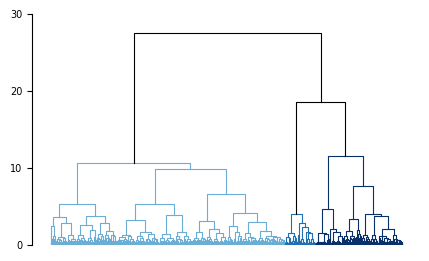

In [89]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, set_link_color_palette
import matplotlib.pyplot as plt
import matplotlib
import distinctipy

fontsize=7
colors = ['#6aaed6','#2070b4','#08306b']
aba_vec = squareform(dist_mat, checks=False)
set_link_color_palette(colors)
# Generate linkage
Z = linkage(aba_vec, method='ward')


x_shift = 1000

fig, ax = plt.subplots(figsize=(5, 3))


dn = dendrogram(Z, no_plot=True, labels=a.id,color_threshold=15)

for xs, ys, color in zip(dn['icoord'], dn['dcoord'], dn['color_list']):
    if max(ys) > 15:
        draw_color = 'black'
    else:
        draw_color = color
    ax.plot([x + x_shift for x in xs], ys, color=draw_color,linewidth=0.8)

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_ylabel("Distance")
ax.set_xticks([])
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_yticks(np.arange(0,31,10),np.arange(0,31,10),fontsize=fontsize)
ax.set_ylabel('')
# plt.savefig('morphological_clustering_first_clusters.svg',bbox_inches='tight')

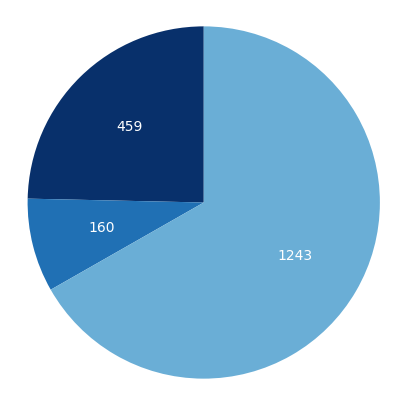

In [90]:
cells = np.array(dn['ivl'])
colors = np.array(dn['leaves_color_list'])
color2num = {}
for c in np.unique(colors):
    color2num[c] = np.sum(colors==c)
    
sizes = list(color2num.values())
colors = list(color2num.keys())

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{count}'
    return my_autopct

plt.figure(figsize=(5,5))
plt.pie(
    sizes,
#     labels=labels,
    autopct=make_autopct(sizes),
    startangle=90,
    colors=colors,
    textprops={'color': 'white'}
)
plt.axis('equal')
plt.show()

In [91]:
cells = np.array(dn['ivl'])
colors = np.array(dn['leaves_color_list']) 

firstgroup2cell = {}
for c in np.unique(colors):
    firstgroup2cell[c] = cells[colors==c]
    
# with open('firstgroup2cell.pkl','wb') as f:
#     pickle.dump(firstgroup2cell,f)

cells = np.array(dn['ivl'])
colors = np.array(dn['leaves_color_list'])
subgroup = cells[colors=='#08306b']
dist_mat_sub = dist_mat.loc[subgroup, subgroup]


Text(0, 0.5, '')

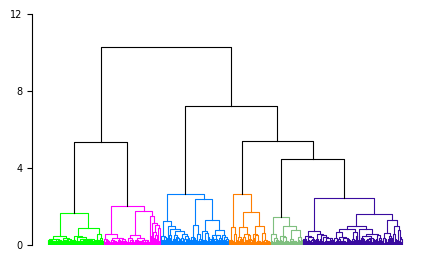

In [92]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, set_link_color_palette
import distinctipy

def rgb_to_hex(rgb):
    r,g,b = rgb
    return '#{:02X}{:02X}{:02X}'.format(r, g, b)
    


colors = ['#00ff00','#ff00ff','#007fff','#ff7f00','#7fbf7f','#390B9F']
aba_vec = squareform(dist_mat_sub, checks=False)
set_link_color_palette(colors)

# Generate linkage
Z = linkage(aba_vec, method='ward')


x_shift = 200

fig, ax = plt.subplots(figsize=(5, 3))

threshold = 3.8
dn = dendrogram(Z, no_plot=True, labels=subgroup,color_threshold=threshold)

for xs, ys, color in zip(dn['icoord'], dn['dcoord'], dn['color_list']):
    if max(ys) > threshold:
        draw_color = 'black'
    else:
        draw_color = color
    ax.plot([x + x_shift for x in xs], ys, color=draw_color,linewidth=0.8)

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_ylabel("Distance")
ax.set_xticks([])
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_yticks(np.arange(0,15,4),np.arange(0,15,4),fontsize=fontsize)
ax.set_ylim([0,12])
ax.set_ylabel('')
# plt.savefig('morphological_clustering_second_clusters.svg',bbox_inches='tight')



In [93]:
cells = np.array(dn['ivl'])
colors = np.array(dn['leaves_color_list'])
color2num = {}
for c in np.unique(colors):
    color2num[c] = np.sum(colors==c)
    
color2num

{'#007fff': 88,
 '#00ff00': 72,
 '#390B9F': 129,
 '#7fbf7f': 42,
 '#ff00ff': 74,
 '#ff7f00': 54}

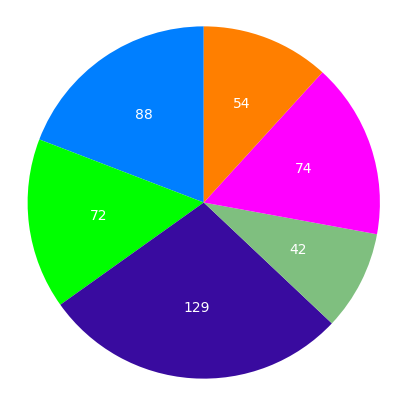

In [94]:
cells = np.array(dn['ivl'])
colors = np.array(dn['leaves_color_list'])
color2num = {}
for c in np.unique(colors):
    color2num[c] = np.sum(colors==c)
    
sizes = list(color2num.values())
colors = list(color2num.keys())

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{count}'
    return my_autopct

plt.figure(figsize=(5,5))
plt.pie(
    sizes,
#     labels=labels,
    autopct=make_autopct(sizes),
    startangle=90,
    colors=colors,
    textprops={'color': 'white'}
)
plt.axis('equal')
plt.show()

In [96]:
color2num

{'#007fff': 88,
 '#00ff00': 72,
 '#390B9F': 129,
 '#7fbf7f': 42,
 '#ff00ff': 74,
 '#ff7f00': 54}

In [95]:
cells = np.array(dn['ivl'])
colors = np.array(dn['leaves_color_list']) 

secondgroup2cell = {}
for c in np.unique(colors):
    secondgroup2cell[c] = cells[colors==c]
    
with open('secondgroup2cell.pkl','wb') as f:
    pickle.dump(secondgroup2cell,f)


In [99]:
pickle.dump(putative_GRNs,open('GRN_candidates.pkl','wb'))

In [100]:
putative_GRNs

array([720575940632341452, 720575940631106664, 720575940622358057,
       720575940625752778, 720575940627397263, 720575940630229007,
       720575940616971035, 720575940606254002, 720575940622236671,
       720575940625615705, 720575940611018714, 720575940628832256,
       720575940627265265, 720575940624604560, 720575940629211607,
       720575940619387814, 720575940615089369, 720575940614273292,
       720575940632293346, 720575940620856046, 720575940622371037,
       720575940612556402, 720575940630882039, 720575940630968335,
       720575940634278295, 720575940631331855, 720575940632146340,
       720575940614734186, 720575940634683743, 720575940630597839,
       720575940622853011, 720575940637580102, 720575940638813016,
       720575940625696601, 720575940643065032, 720575940627402568,
       720575940625450498, 720575940621898665, 720575940637747519,
       720575940611849178, 720575940631204163, 720575940624976572,
       720575940627438906, 720575940626241636, 720575940615274